# Lab - Parallel Computing Part 3 - PyTorch Classifier Training
## E6692 Spring 2026

In this part we train a PyTorch CNN classifier from scratch as we did last week, and predict the value of handwritten MNIST digits. This is a classic machine learning task, so you've likely seen it before. We provide the data download, model definition, and training code, so running these cells should output an MNIST trained instance of the **utils.models.PyTorchClassifier** model with weights saved to **models/MNIST classification**. 

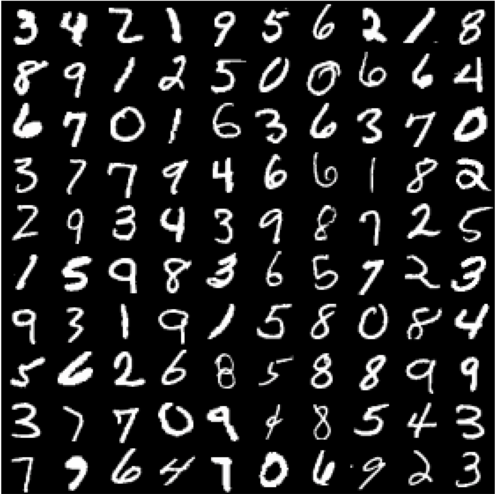

After you have generated the trained model, we will transfer its weight parameters to a model that uses the CUDA kernel function layers we implemented in Part 1. 

## <font color="red"><strong>TODO:</strong></font> Run all the cells below to train a PyTorch classifier.

### <font color="red"><strong>WARNING:</strong></font> The Jetson Nano might overheat during training. Please Commit and Push all your changes to your GitHub repository to save your progress before training your model!

### <font color="red"><strong>NOTE:</strong></font> If you get a "Cannot Allocate Memory" error during training, try shutting down your other active kernels to free the memory.

In [1]:
import os
import torch
import torchvision
import numpy as np

from utils.dataset import load_mnist_dataset, display_image, BATCH_SIZE, CLASSES
from utils.models import PyTorchClassifier
from utils.train import train, plot_loss_and_accuracy

device = torch.device('cuda')
print("GPU name: ", torch.cuda.get_device_name(0))

models_path = './models'
if not os.path.exists(models_path):
    os.makedirs(models_path)
    
model_save_path = os.path.join(models_path, 'MNIST classification')

%load_ext autoreload
%autoreload 2

%matplotlib inline

GPU name:  NVIDIA Tegra X1


In [2]:
training_set, validation_set = load_mnist_dataset()

# change the training and validation set sizes in utils/dataset.py
print("\nNumber of training images: ", int(len(training_set) * BATCH_SIZE), "shape: ", iter(training_set).next()[0][0].numpy().shape)
print("\nNumber of training images: ", int(len(validation_set) * BATCH_SIZE), "shape: ", iter(validation_set).next()[0][0].numpy().shape)


/usr/local/lib/python3.6/dist-packages/torchvision-0.10.0a0+300a8a4-py3.6-linux-aarch64.egg/torchvision/datasets/mnist.py:498: UserWarning: The given NumPy array is not writeable, and PyTorch does not support non-writeable tensors. This means you can write to the underlying (supposedly non-writeable) NumPy array using the tensor. You may want to copy the array to protect its data or make it writeable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  /media/nvidia/NVME/pytorch/pytorch-v1.9.0/torch/csrc/utils/tensor_numpy.cpp:180.)
  return torch.from_numpy(parsed.astype(m[2], copy=False)).view(*s)



Number of training images:  1000 shape:  (1, 28, 28)

Number of training images:  100 shape:  (1, 28, 28)


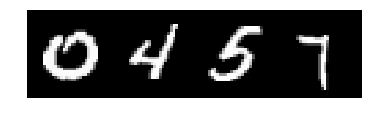

0     4     5     7    


In [3]:
sample_images, sample_labels = iter(training_set).next()
sample_images_grid = torchvision.utils.make_grid(sample_images)

display_image(sample_images_grid)
print(' '.join(f'{CLASSES[sample_labels[j]]:5s}' for j in range(BATCH_SIZE)))

In [4]:
model = PyTorchClassifier()
model.to(device) # transfer model to GPU


PyTorchClassifier(
  (conv1): Conv2d(1, 1, kernel_size=(5, 5), stride=(1, 1), padding=same, bias=False)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(1, 1, kernel_size=(5, 5), stride=(1, 1), padding=same, bias=False)
  (fc1): Linear(in_features=49, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [5]:
epochs = 10
optimizer = torch.optim.Adam(model.parameters())

train_loss, train_accuracy, val_loss, val_accuracy = train(model, device, training_set, 
                                                           validation_set, epochs, optimizer,
                                                           model_save_path)

Epoch: 1


/usr/local/lib/python3.6/dist-packages/torch/nn/functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  /media/nvidia/NVME/pytorch/pytorch-v1.9.0/c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


Saving model.
Training Loss: 0.4249	 Training Accuracy: 0.427
Validation Loss: 0.2478	 Validation Accuracy: 0.67
Epoch: 2
Saving model.
Training Loss: 0.1824	 Training Accuracy: 0.77
Validation Loss: 0.1734	 Validation Accuracy: 0.78
Epoch: 3
Saving model.
Training Loss: 0.1229	 Training Accuracy: 0.843
Validation Loss: 0.1406	 Validation Accuracy: 0.82
Epoch: 4
Training Loss: 0.0988	 Training Accuracy: 0.871
Validation Loss: 0.1451	 Validation Accuracy: 0.8
Epoch: 5
Saving model.
Training Loss: 0.0817	 Training Accuracy: 0.891
Validation Loss: 0.1021	 Validation Accuracy: 0.87
Epoch: 6
Training Loss: 0.073	 Training Accuracy: 0.91
Validation Loss: 0.0853	 Validation Accuracy: 0.87
Epoch: 7
Saving model.
Training Loss: 0.0615	 Training Accuracy: 0.914
Validation Loss: 0.0796	 Validation Accuracy: 0.89
Epoch: 8
Saving model.
Training Loss: 0.0541	 Training Accuracy: 0.926
Validation Loss: 0.0955	 Validation Accuracy: 0.9
Epoch: 9
Training Loss: 0.0457	 Training Accuracy: 0.941
Validatio

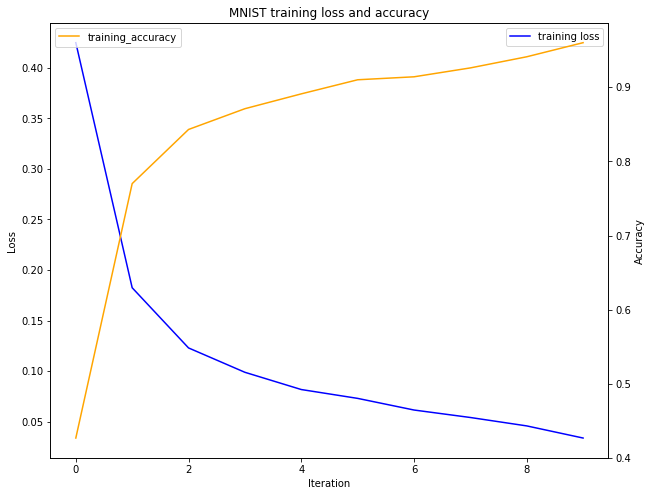

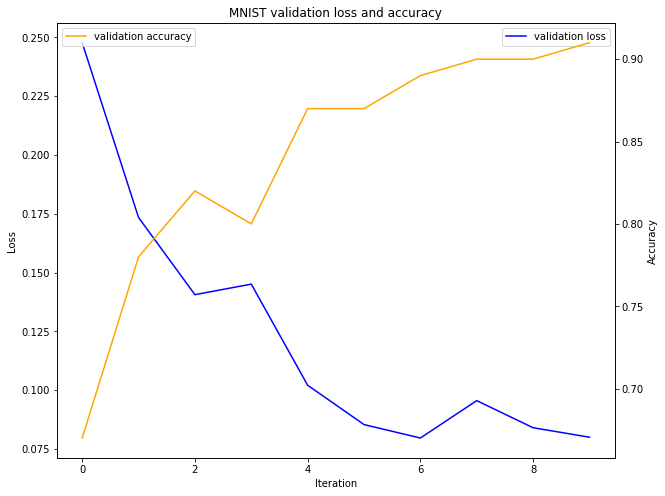

In [6]:
train_title = "MNIST training loss and accuracy"
train_labels = ["training loss", "training_accuracy"]
plot_loss_and_accuracy(train_loss, train_accuracy, train_title, train_labels)

val_title = "MNIST validation loss and accuracy"
val_labels = ["validation loss", "validation accuracy"]
plot_loss_and_accuracy(val_loss, val_accuracy, val_title, val_labels)